## 各船の船舶ログから偏流を計算するまでの流れ
1. 複数のログファイルをFileConection.ipynbで１つのファイルにする
1. S1-ShipLogToS1でファイルから必要な情報を抜き出す
1. このファイル(環境省の船舶ログから偏流)で各船の偏流を計算

## import files

In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
from tqdm import tqdm
import pickle as pkl
import math
import os 
import os.path as osp

import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", color_codes=True)

from utils import *
from kf_params import *

## 関数の定義

In [2]:
## 関数の定義

## データの読み込みとデータ操作

In [182]:
dt_year = 2015
dt_month = 9
dt_day = 1

log_data = None
path_log = "./data/shipLog/2015-09/興春"
filename = f"興春丸FileOut{dt_year}{dt_month:02}{dt_day:02}.slog1"
log = pd.read_csv(osp.join(path_log, filename), encoding="cp932", header=None)
if log_data==None:
    log_data = log
else:
    log_data = pd.concat([log_data, log])
log_data.columns = ["UTC", "NMEA", "data1", "data2"]

In [183]:
log_data

,UTC,NMEA,data1,data2
0,2015/08/31 15:00:00,VBW,9.000,-999.000
1,2015/08/31 15:00:00,GGA,3353.409,13114.135
2,2015/08/31 15:00:00,VTG,5.700,8.400
3,2015/08/31 15:00:00,HDT,3.000,NaN
4,2015/08/31 15:00:01,GGA,3353.412,13114.135
...,...,...,...,...
262366,2015/09/01 14:59:58,VTG,29.900,0.100
262367,2015/09/01 14:59:58,HDT,301.000,NaN
262368,2015/09/01 14:59:59,GGA,3354.335,13114.114
262369,2015/09/01 14:59:59,VTG,29.900,0.000


In [184]:
# 時間の整理
time_utc =log_data["UTC"].values
str_format = '%Y/%m/%d %H:%M:%S'
epoc_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
time_idx = []
time_idx2 = []
tf = []
for t in time_utc:
    idx = datetime.datetime.strptime(t, str_format) 
    idx2 = idx - epoc_dt
    time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
    time_idx2.append(int(idx2.days*24*60 + idx2.seconds / (60)))
time_idx = np.array(time_idx)
time_idx2 = np.array(time_idx2)
log_data["DtIdx"] = time_idx
log_data["DtIdx_Minute"] = time_idx2

# min_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
# min_idx = min_dt - epoc_dt
# min_idx = int(min_idx.days*24 + min_idx.seconds / (60*60))
# log_data = log_data[log_data["DtIdx"] >= min_idx]

gga = log_data[log_data["NMEA"]=="GGA"]
gga.columns = ['UTC', 'NMEA', 'LatDMS', 'LonDMS', 'DtIdx', 'DtIdx_Minute']
gga['Lat'] = dms_to_deg_df(gga['LatDMS'])
gga['Lon'] = dms_to_deg_df(gga['LonDMS'])

vbw = log_data[log_data["NMEA"]=="VBW"]
vbw.columns = ['UTC', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx', 'DtIdx_Minute']

hdt = log_data[log_data["NMEA"]=="HDT"]
hdt = hdt.drop('data2', axis=1)
hdt.columns = ['UTC', 'NMEA', 'HeadDeg', 'DtIdx', 'DtIdx_Minute']

vtg = log_data[log_data["NMEA"]=="VTG"]
vtg.columns = ['UTC', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx', 'DtIdx_Minute']

In [185]:
values_set = set((vbw["LonWaterSpeed"]).astype(str) + " " 
                 + vbw["TraWaterSpeed"].astype(str))

forbidden_values = {'0.0 0.0', '0.0 -999.0', '-999.0 0.0', '-999.0 -999.0'}
dtIdx = []
dtIdx_m = []
lonSpeed = []
traSpeed = []
for v in values_set:
    tf = (v == (vbw["LonWaterSpeed"]).astype(str) + " " 
                + vbw["TraWaterSpeed"].astype(str))
    if not v in forbidden_values:
        dtIdx.append(vbw[tf]['DtIdx'].values.tolist())
        dtIdx_m += vbw[tf]['DtIdx_Minute'].values.tolist()
        ls = vbw[tf]['LonWaterSpeed'].values
        ls[ls==-999.0] = 0.0
        lonSpeed.append(ls.tolist())
        ts = vbw[tf]['TraWaterSpeed'].values
        ts[ts==-999.0] = 0.0
        traSpeed.append(ts.tolist())
dtIdx = sum(dtIdx, [])
lonSpeed = sum(lonSpeed, [])
traSpeed = sum(traSpeed, [])

vbw2 = pd.DataFrame([])
vbw2['DtIdx'] = dtIdx
vbw2['DtIdx_Minute'] = dtIdx_m
vbw2['LonWaterSpeed'] = lonSpeed
vbw2['TraWaterSpeed'] = traSpeed
vbw = vbw2

In [186]:
hdt

,UTC,NMEA,HeadDeg,DtIdx,DtIdx_Minute
3,2015/08/31 15:00:00,HDT,3.0,-9,-540
6,2015/08/31 15:00:01,HDT,3.0,-8,-539
9,2015/08/31 15:00:02,HDT,3.0,-8,-539
12,2015/08/31 15:00:02,HDT,3.0,-8,-539
15,2015/08/31 15:00:03,HDT,3.0,-8,-539
...,...,...,...,...,...
262358,2015/09/01 14:59:55,HDT,301.0,14,899
262361,2015/09/01 14:59:56,HDT,301.0,14,899
262364,2015/09/01 14:59:57,HDT,301.0,14,899
262367,2015/09/01 14:59:58,HDT,301.0,14,899


In [187]:
hdt2 =  hdt[hdt["DtIdx_Minute"]==-539]
hdt2[['HeadDeg']].describe()

,HeadDeg
count,66.000000
mean,83.166667
std,150.416609
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,359.000000


In [188]:
time_set = sorted(set(gga["DtIdx_Minute"]))

delete_time = []
delete_range = 10
thres = 10
for i in range(len(time_set)-1):
        hdt1 = hdt[time_set[i] == hdt["DtIdx_Minute"]]
        hdt2 = hdt[time_set[i+1] == hdt["DtIdx_Minute"]]
        q1 = hdt1.HeadDeg.quantile(0.95)
        q2 = hdt2.HeadDeg.quantile(0.95)
        omega = (q2 - q1)/(time_set[i+1]-time_set[i])
        #print(omega)
        
        time = time_set[i]
        if np.abs(omega)>thres and 360-np.abs(omega)>thres:
            print(f'value: {omega}, time:{time}')
            delete_time.append(time)
            for j in range(1, 10):
                delete_time.append(time-j)
                delete_time.append(time+j)

delete_time = sorted(set(delete_time))
print(delete_time)                              

value: -16.600000000000023, time:-533
value: 90.0, time:-355
value: -102.0, time:-354
value: 11.0, time:-289
value: 95.39999999999998, time:-274
value: -108.39999999999998, time:-273
value: 105.95, time:-268
value: -91.0, time:-267
value: -10.950000000000003, time:-263
value: -10.049999999999997, time:-262
value: 119.95, time:-258
value: -105.0, time:-257
value: -11.0, time:-253
value: 11.950000000000003, time:-250
value: 13.0, time:-249
value: -11.950000000000003, time:-245
value: -10.049999999999997, time:-244
value: 11.049999999999997, time:-241
value: 11.0, time:-223
value: 11.0, time:-215
value: -12.0, time:-210
value: 10.950000000000003, time:-198
value: -12.0, time:-193
value: 14.199999999999704, time:-190
value: 95.0, time:-186
value: -112.0, time:-185
value: -14.699999999999733, time:-166
value: -10.950000000000003, time:-157
value: -11.0, time:-147
value: 113.0, time:-134
value: -95.0, time:-133
value: -11.0, time:-128
value: 12.849999999999724, time:-125
value: 13.3499999999

In [189]:
delete_time_set = set(delete_time_set)
delete_time_set.add(-542)

In [207]:
time_set = sorted(set(gga["DtIdx_Minute"]))

delete_range = 10
thres = 15 #knot
for i in range(len(time_set)-1):
        gga1 = gga[time_set[i] == gga["DtIdx_Minute"]]
        gga2 = gga[time_set[i+1] == gga["DtIdx_Minute"]]
        lat1 = gga1.Lat.quantile(0.95)
        lon1 = gga1.Lon.quantile(0.95)
        lat2 = gga2.Lat.quantile(0.95)
        lon2 = gga2.Lon.quantile(0.95)
        distance = haversine_distance(lat1, lon1, lat2, lon2)
        knot = (distance/(time_set[i+1]-time_set[i])) * 0.0194384
        #print(f'value: {knot}, time:{time}')
        
        time = time_set[i]
        if np.abs(knot)>thres:
            print(f'value: {knot}, time:{time}')
            delete_time.append(time)
            for j in range(1, 10):
                delete_time.append(time-j)
                delete_time.append(time+j)

delete_time = sorted(set(delete_time))
print(delete_time)   


value: 15.739000492984996, time:-534
value: 19.782099481132544, time:-235
value: 19.634536377132363, time:-234
value: 19.63261171426475, time:-227
value: 19.63552374352472, time:-225
value: 19.683531271718536, time:-219
value: 19.6345171842592, time:-217
value: 19.58470781148602, time:-211
value: 19.58689731303838, time:-209
value: 19.68288706448513, time:-202
value: 19.53586557432915, time:-200
value: 19.534866577806678, time:-194
value: 19.586890932361342, time:-192
value: 19.583882696758753, time:-185
value: 19.63552374352472, time:-183
value: 19.584701430102914, time:-176
value: 19.68351202930814, time:-174
value: 19.732700129388025, time:-166
value: 19.633687781112872, time:-165
value: 19.633048352763254, time:-157
value: 19.486033453165184, time:-155
value: 19.633687781112872, time:-148
value: 19.53585284465234, time:-145
value: 19.681046469731548, time:-138
value: 19.48602075595453, time:-135
value: 19.583844406785317, time:-129
value: 19.48500642475284, time:-126
value: 19.6336

## データの確認

In [208]:
gga

,UTC,NMEA,LatDMS,LonDMS,DtIdx,DtIdx_Minute,Lat,Lon
1,2015/08/31 15:00:00,GGA,3353.409,13114.135,-9,-540,33.894694,131.237083
4,2015/08/31 15:00:01,GGA,3353.412,13114.135,-8,-539,33.894778,131.237083
7,2015/08/31 15:00:02,GGA,3353.414,13114.135,-8,-539,33.894833,131.237083
10,2015/08/31 15:00:02,GGA,3353.416,13114.135,-8,-539,33.894889,131.237083
13,2015/08/31 15:00:03,GGA,3353.416,13114.135,-8,-539,33.894889,131.237083
...,...,...,...,...,...,...,...,...
262356,2015/09/01 14:59:55,GGA,3354.335,13114.114,14,899,33.909306,131.236500
262359,2015/09/01 14:59:56,GGA,3354.335,13114.114,14,899,33.909306,131.236500
262362,2015/09/01 14:59:57,GGA,3354.335,13114.114,14,899,33.909306,131.236500
262365,2015/09/01 14:59:58,GGA,3354.335,13114.114,14,899,33.909306,131.236500


In [209]:
gga1 = gga[gga['Lon']>131.244]
gga1

,UTC,NMEA,LatDMS,LonDMS,DtIdx,DtIdx_Minute,Lat,Lon
55821,2015/08/31 20:05:06,GGA,3354.376,13113.998,-3,-234,33.910444,131.244389
55824,2015/08/31 20:05:07,GGA,3354.376,13113.998,-3,-234,33.910444,131.244389
55827,2015/08/31 20:05:08,GGA,3354.376,13113.998,-3,-234,33.910444,131.244389
55830,2015/08/31 20:05:09,GGA,3354.376,13113.998,-3,-234,33.910444,131.244389
55833,2015/08/31 20:05:10,GGA,3354.376,13113.998,-3,-234,33.910444,131.244389
...,...,...,...,...,...,...,...,...
200191,2015/09/01 9:18:21,GGA,3354.385,13113.999,9,558,33.910694,131.244417
200194,2015/09/01 9:18:22,GGA,3354.385,13113.999,9,558,33.910694,131.244417
200197,2015/09/01 9:18:23,GGA,3354.385,13113.999,9,558,33.910694,131.244417
200200,2015/09/01 9:18:24,GGA,3354.385,13113.999,9,558,33.910694,131.244417


In [210]:
vbw = vbw.sort_values('DtIdx')
vbw = vbw.reset_index(drop=True)
vbw

,DtIdx,DtIdx_Minute,LonWaterSpeed,TraWaterSpeed
0,-9,-540,9.0,0.0
1,-8,-482,0.6,0.0
2,-8,-498,0.9,0.0
3,-8,-533,4.5,0.0
4,-8,-481,0.9,0.0
...,...,...,...,...
1102,14,840,0.3,0.0
1103,14,843,0.3,0.0
1104,14,845,0.3,0.0
1105,14,884,0.6,0.0


In [211]:
# # 0.3はおそらく動いてない（GPSが動いていない）
# tf = (vbw['LonWaterSpeed']==0.3)
# np.min(vbw[tf]['DtIdx'])

<Axes: xlabel='Lon', ylabel='Lat'>

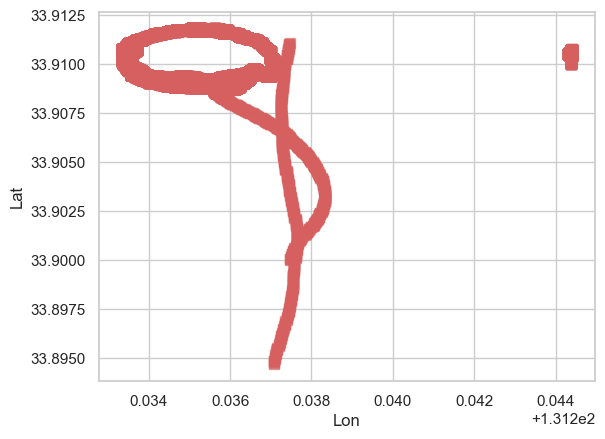

In [212]:
gga.plot.scatter(x='Lon', y='Lat',
                marker='s', c='r', s=50, alpha=0.5)

## 偏流の計算

## knotの単位確認も忘れずに

In [213]:

#各速度の閾値超えたら１０分ぶんのでーた捨てる
#はずれた値のデータも捨てる
min_timeHours = np.min(gga["DtIdx"])
max_timeHours = np.max(gga["DtIdx"])
num_timeHours = max_timeHours - min_timeHours + 1

grids0 = []
grids1 = []
curN = []
curE = []
timeMinutes = []
timeHours = []
UTC_time = []
lats = []
lons = []
curN_grid = {}
curE_grid = {}
count_grid = {}

time_set_h = set(gga["DtIdx"])
for s in time_set_h:
    curN_grid[s] = np.zeros(nan_map.shape)
    curE_grid[s] = np.zeros(nan_map.shape)
    count_grid[s] = np.zeros(nan_map.shape) 

time_set = set(gga["DtIdx_Minute"])
for time in time_set:
    if time in delete_time:
        continue
    # 時間ごとの平均で偏流を求める
    gga1 = gga[time == gga["DtIdx_Minute"]]
    vbw1 = vbw[time == vbw["DtIdx_Minute"]]
    hdt1 = hdt[time == hdt["DtIdx_Minute"]]
    vtg1 = vtg[time == vtg["DtIdx_Minute"]]
    if (len(vbw1)==0 or len(gga)==0 or len(hdt1)==0 or len(vtg1)==0):
        continue

    # GGAからLat Lon 取得
    # 分位数95%の値（）
    lat1 = gga1.Lat.quantile(0.95)
    lon1 = gga1.Lon.quantile(0.95)
    #lat1 = np.mean(gga1["Lat"])
    #lon1 = np.mean(gga1["Lon"])

    # HDTから船首方位取得
    # head_rat = deg_to_rat(np.mean(hdt1["HeadDeg"]))
    head_rat = deg_to_rat(hdt1.HeadDeg.quantile(0.95))

    # VBWから対船水速取得
    #water_speed = np.mean(vbw1["LonWaterSpeed"].values)
    water_speed = vbw1.LonWaterSpeed.quantile(0.95)

    # VTGから船首方位・対地船速取得
    #g_head_rat = deg_to_rat(np.mean(vtg1["HeadDeg"])) #FIXME min 
    #ground_speed = np.mean(vtg1["GroundSpeed"])
    g_head_rat = deg_to_rat(vtg1.HeadDeg.quantile(0.95)) 
    ground_speed = np.mean(vtg1.GroundSpeed.quantile(0.95))

    # 偏流の計算
    curN.append(ground_speed*np.sin(g_head_rat) - water_speed*np.sin(head_rat))
    curE.append(ground_speed*np.cos(g_head_rat) - water_speed*np.cos(head_rat))

    # Gridの位置計算
    grid0, grid1 = latlon_to_mesh(lat1, lon1)

    grids0.append(grid0)
    grids1.append(grid1)
    lats.append(lat1)
    lons.append(lon1)

    UTC_time.append(gga1['UTC'].values[-1][:-6])
    timeMinutes.append(time)
    timeHours.append(gga1['DtIdx'].values[-1])
    curN_grid[timeHours[-1]][grid0][grid1] += curN[-1]
    curE_grid[timeHours[-1]][grid0][grid1] += curE[-1]
    count_grid[timeHours[-1]][grid0][grid1] += 1

grid_cur_m = pd.DataFrame([])
grid_cur_m["DtIdx"] = timeHours
grid_cur_m["DtIdx_Minute"] = timeMinutes
grid_cur_m["UTC"] = UTC_time
grid_cur_m["CurN"] = curN
grid_cur_m["CurE"] = curE
grid_cur_m["Grid0"] = grids0
grid_cur_m["Grid1"] = grids1
grid_cur_m["Lat"] = lats
grid_cur_m["Lon"] = lons

for i in time_set_h:
    count_grid[i][count_grid[i] == 0] += 1
    curN_grid[i] = curN_grid[i]/count_grid[i]
    curE_grid[i] = curE_grid[i]/count_grid[i]


<Axes: xlabel='Lon', ylabel='Lat'>

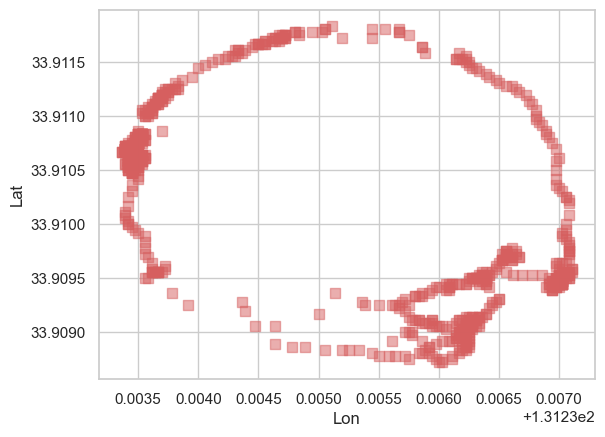

In [214]:
grid_cur_m.plot.scatter(x='Lon', y='Lat',
                marker='s', c='r', s=50, alpha=0.5)

In [215]:
target = grid_cur_m[grid_cur_m['Lon']>131.244]
target

,DtIdx,DtIdx_Minute,UTC,CurN,CurE,Grid0,Grid1,Lat,Lon


In [199]:
grids0 = []
grids1 = []
curN = []
curE = []
timeHours = []
UTC_time = []
lats = []
lons = []

time_set = set(grid_cur_m["DtIdx"])
for time in time_set:
    target = grid_cur_m[time == grid_cur_m["DtIdx"]]
    timeHours.append(time)
    UTC_time.append(target["UTC"].values[0])
    lats.append(target.Lat.quantile(0.95))
    lons.append(target.Lon..quantile(0.95))
    grids0.append(int(target.Grid0.quantile(0.95)))
    grids1.append(int(target.Grid1.quantile(0.95)))
    curN.append(targetCurN.quantile(0.95))
    curE.append(target.CurE.quantile(0.95))
#     lats.append(np.mean(target["Lat"].values))
#     lons.append(np.mean(target["Lon"].values))
#     grids0.append(int(np.mean(target["Grid0"].values)))
#     grids1.append(int(np.mean(target["Grid1"].values)))
#     curN.append(np.mean(target["CurN"].values))
#     curE.append( np.mean(target["CurE"].values))
grid_cur = pd.DataFrame([])
grid_cur["DtIdx"] = timeHours
grid_cur["UTC"] = UTC_time
grid_cur["CurN"] = curN
grid_cur["CurE"] = curE
grid_cur["Grid0"] = grids0
grid_cur["Grid1"] = grids1
grid_cur["Lat"] = lats
grid_cur["Lon"] = lons

SyntaxError: invalid syntax (335342820.py, line 16)

In [ ]:
grid_cur_m = grid_cur_m.sort_values('DtIdx_Minute')
grid_cur_m = grid_cur_m.reset_index(drop=True)
grid_cur = grid_cur.sort_values('DtIdx')
grid_cur = grid_cur.reset_index(drop=True)


In [ ]:
# 各時間のデータ数
grid_cur

## データの保存

In [ ]:
# 保存
save_path = osp.join(path_log, "cur_hours.csv")
grid_cur.to_csv(save_path)

save_path = osp.join(path_log, "cur_minutes.csv")
grid_cur_m.to_csv(save_path)
print(save_path)

In [ ]:
pkl.dump(curN_grid, open(osp.join(path_log, "curGridN.pkl"), 'wb'))
pkl.dump(curE_grid, open(osp.join(path_log, "curGridE.pkl"), 'wb'))

In [ ]:
# 保存
# keys = grid_cur.keys()
# out = {}
# for k in keys:
#     out[k] = grid_cur[k]

# pkl.dump(out, open(osp.join(path_log, "cur.pkl"), 'wb'))

In [ ]:
# pkl.dump(grid_cur, open(osp.join(path_log, "cur.pkl"), 'wb'))
# pkl.dump(grid_cur_m, open(osp.join(path_log, "cur_minus.pkl"), 'wb'))